# 00 - Data Collection

Download **all datasets in one run**, build a **per-dataset manifest** (`data/<dataset-name>/manifest.csv`) for each, and show sample images per dataset at the end. Later notebooks read the manifests.

| Name | Size | Generators | Resolution | Role |
|------|------|-----------|-----------|------|
| `ai-real-images` | 60k (30k/30k) | SD + Midjourney + DALL·E | photo-res | **Primary** — training/eval |
| `tiny-genimage` | 35k | 7 (biggan, vqdm, sdv5, wukong, adm, glide, midjourney) | 256px | Cross-generator **OOD** test |

Their folder layouts differ (`split/label` vs `generator/split/label`, lowercase vs uppercase labels), so the manifest builder **infers `label` / `split` / `source` from folder names** rather than assuming one structure.

**Sections:** 0 Setup · 1 Download all · 2 Build & save manifests · 3 Verify & sample.

Downloads use **`kagglehub`** (needs Kaggle credentials — `~/.kaggle/kaggle.json` or `KAGGLE_USERNAME`/`KAGGLE_KEY`). The big one (`ai-real-images`, ~48 GB) takes a while the first time; subsequent runs are instant from cache. Manual fallback: unzip a dataset under `data/<dataset-name>/`.

## 0 - Setup

Make `utils` importable, resolve project paths, and list the datasets to collect (all of `utils.data.KAGGLE_SLUGS`).

In [2]:
import sys
from pathlib import Path

# Make notebooks/ importable so `from utils import ...` works from any CWD.
_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import data as dutils
from utils.paths import repo_paths

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]

# Collect every known dataset this run.
DATASETS = list(dutils.KAGGLE_SLUGS)

print("Repo root:", PATHS["root"])
print("Datasets :", DATASETS)

Repo root: C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks
Datasets : ['ai-real-images', 'tiny-genimage']


## 1 - Download all

For each dataset: use a local copy under `data/<dataset-name>/` if it already holds images, otherwise fetch via `kagglehub` (instant if cached). Resolve each dataset's **root** (the folder that actually contains the data) and keep them in `roots`.

In [3]:
roots = {}
for name in DATASETS:
    local = DATA_DIR / name
    if local.exists() and any(dutils.iter_images(local)):
        path = local
        print(f"{name:16s} using local data")
    else:
        print(f"{name:16s} fetching via kagglehub...")
        path = dutils.download_kaggle_dataset(dutils.KAGGLE_SLUGS[name])
    roots[name] = dutils.find_dataset_root(path)
    print(f"{'':16s}  root -> {roots[name]}")

ai-real-images   fetching via kagglehub...


100%|██████████| 48.4G/48.4G [28:17<00:00, 30.6MB/s]   

Extracting files...


                  root -> C:\Users\ΜΑΤΟΥΛΑ\.cache\kagglehub\datasets\tristanzhang32\ai-generated-images-vs-real-images\versions\2
tiny-genimage    fetching via kagglehub...


100%|██████████| 7.77G/7.77G [04:28<00:00, 31.0MB/s]  

Extracting files...


                  root -> C:\Users\ΜΑΤΟΥΛΑ\.cache\kagglehub\datasets\yangsangtai\tiny-genimage\versions\1


## 2 - Build & save manifests

Build one manifest per dataset — each row has `filepath, filename, label` (real/fake), `split` (train/test/val), `source` (per-generator folder, if any), and a `dataset` tag. Labels/splits are inferred from folder names. Saved to `data/<dataset-name>/manifest.csv` (absolute paths; `data/` is gitignored). We keep them in `manifests` for inspection below.

In [4]:
manifests = {}
for name in DATASETS:
    m = dutils.build_manifest(roots[name])
    m["dataset"] = name
    out = DATA_DIR / name / "manifest.csv"
    out.parent.mkdir(parents=True, exist_ok=True)
    m.to_csv(out, index=False)
    manifests[name] = m
    print(f"{name:16s} rows={len(m):>7,}  ->  {out}")

ai-real-images   rows= 60,000  ->  C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks\data\ai-real-images\manifest.csv
tiny-genimage    rows= 35,000  ->  C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\notebooks\data\tiny-genimage\manifest.csv


## 3 - Verify & sample

Per dataset: confirm every image got a `label`/`split` (no `NaN`), show the per-`source`/`split`/`label` counts, and display one example image per `split`/`label`. Deeper analysis is in `01_eda`.

In [5]:
from IPython.display import display

for name, m in manifests.items():
    unlabeled, nosplit = int(m["label"].isna().sum()), int(m["split"].isna().sum())
    print(f"== {name} ==  total={len(m):,}  unlabeled={unlabeled}  no_split={nosplit}")
    display(dutils.summarize_manifest(m))

== ai-real-images ==  total=60,000  unlabeled=0  no_split=0


,source,split,label,count
0,NaN,test,fake,6000
1,NaN,test,real,6000
2,NaN,train,fake,24000
3,NaN,train,real,24000


== tiny-genimage ==  total=35,000  unlabeled=0  no_split=0


,source,split,label,count
0,imagenet_ai_0419_biggan,train,fake,2000
1,imagenet_ai_0419_biggan,train,real,2000
2,imagenet_ai_0419_biggan,val,fake,500
3,imagenet_ai_0419_biggan,val,real,500
4,imagenet_ai_0419_vqdm,train,fake,2000
5,imagenet_ai_0419_vqdm,train,real,2000
6,imagenet_ai_0419_vqdm,val,fake,500
7,imagenet_ai_0419_vqdm,val,real,500
8,imagenet_ai_0424_sdv5,train,fake,2000
9,imagenet_ai_0424_sdv5,train,real,2000


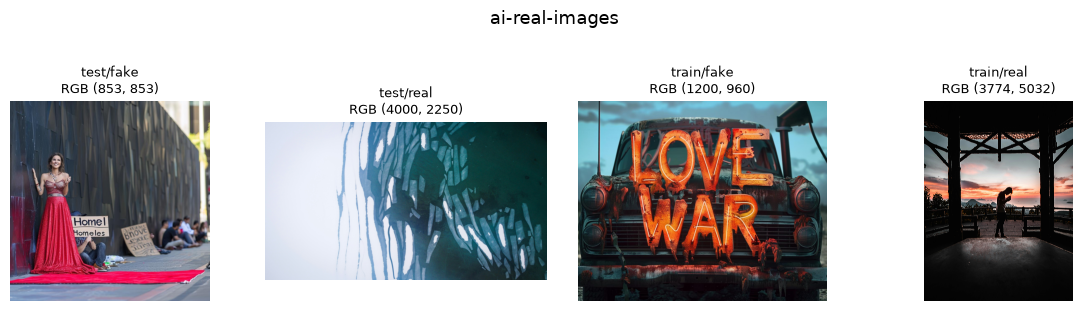

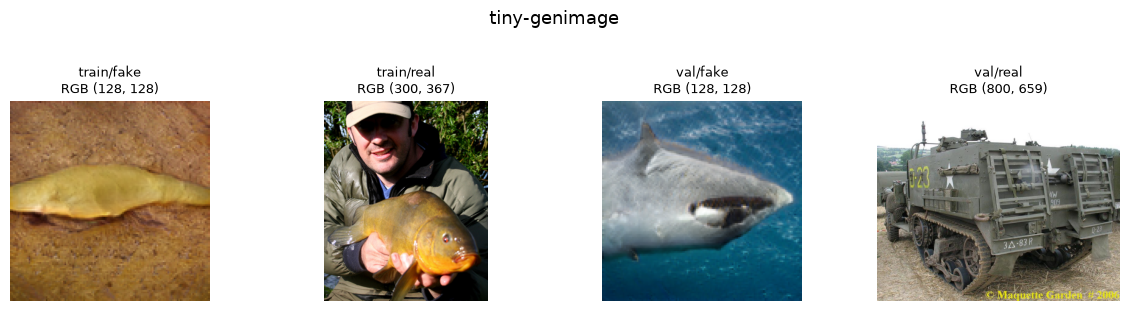

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# One example image per (split, label), one figure per dataset.
for name, m in manifests.items():
    combos = m.groupby(["split", "label"], dropna=False).first().reset_index()
    n = len(combos)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    axes = axes if n > 1 else [axes]
    for ax, filepath, split, label in zip(axes, combos["filepath"], combos["split"], combos["label"]):
        img = Image.open(filepath)
        ax.imshow(img); ax.axis("off")
        ax.set_title(f"{split}/{label}\n{img.mode} {img.size}", fontsize=9)
    fig.suptitle(name, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

**Next:** `01_eda.ipynb` (class balance, real-vs-fake pixel/colour stats, frequency analysis) → `02_cleaning.ipynb` (corrupt/duplicate/leakage checks) → `03_split_and_preprocessing.ipynb` (stratified validation split, normalization stats, canonical transforms).